In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
import pandas as pd
import numpy as np
 
df = pd.read_csv("renewable-share-energy.csv")
latest = df[df["Year"] == 2022].copy()
latest = latest.rename(columns={"Renewables": "renew_share"})
 
# Single column summary
print(latest["renew_share"].describe())
 
# Manual: each statistic, named
print("Mean:    ", latest["renew_share"].mean())
print("Median:  ", latest["renew_share"].median())
print("Std dev: ", latest["renew_share"].std())
print("Skew:    ", latest["renew_share"].skew())
print("Kurtosis:", latest["renew_share"].kurtosis())  
#high kurtosis means more values in the tails and more outliers (kurtosis > 3), 
#low kurtosis implied most values are concentrated near mean and few outliers (kurtosis < 3)


count    111.000000
mean      15.972893
std       14.394260
min        0.005265
25%        6.268038
50%       12.988676
75%       22.162889
max       82.075330
Name: renew_share, dtype: float64
Mean:     15.972893147756757
Median:   12.988676
Std dev:  14.394259750984105
Skew:     1.7747974411433374
Kurtosis: 4.611256081589957


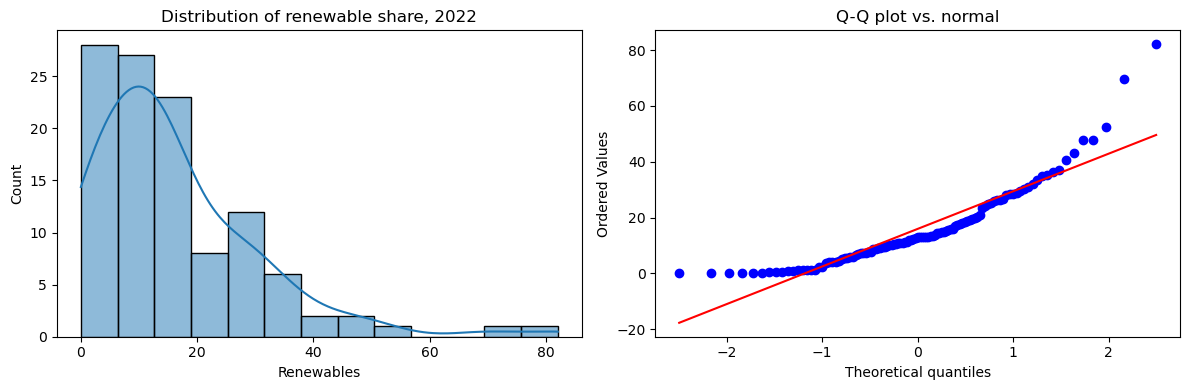

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Histogram with a KDE overlay
sns.histplot(latest["renew_share"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of renewable share, 2022")
axes[0].set_xlabel("Renewables")
 
# Q-Q plot — points on the line = normal
stats.probplot(latest["renew_share"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot vs. normal")
 
plt.tight_layout()
plt.show()


**insights from graph:** 

**1.** The histogram is overlayed with a kernel density estimate. It shows the distribution of renewable energy for electricity in 2022 is highly skewed to the right.

**2.** The quantile-quantile plot is used to check if the data is normally distributed. If data is normally distributed it would fall on the diagonal line. But our data deviates from this line indicating it is not normally distributed. 

In [16]:
x = latest["renew_share"].dropna()
n = len(x)
mean = x.mean()  #this calculates the average renewable share across all countries
se = x.std(ddof=1) / np.sqrt(n)  
#the above calculates the standard error. ddof=1 means we divide 
#by n−1 instead of n when computing std
 
# t-based 95% CI
t_crit = stats.t.ppf(0.975, df=n-1) #finds critical value which is the value at which you can no longer reject null hypothesis
#above, df is the degrees of freedom (equal to 110 in this case) 
ci_low, ci_high = mean - t_crit*se, mean + t_crit*se
 
print(f"Mean: {mean:.2f}")  #2f just means round to 2 decimal points
print(f"95% CI (analytic): [{ci_low:.2f}, {ci_high:.2f}]")


Mean: 15.97
95% CI (analytic): [13.27, 18.68]


Non-normal distribution — the mean (15.97%) sits well above the median (12.99%), skewness is +1.78, and the Shapiro-Wilk test rejects normality (p < 0.001). Most countries cluster at low renewable shares, with a long right tail (Norway at 69%, Iceland at 82%).

In [9]:
boot_means = [x.sample(n, replace=True).mean() for _ in range(5000)]
ci_low_b, ci_high_b = np.percentile(boot_means, [2.5, 97.5])
print(f"95% CI (bootstrap): [{ci_low_b:.2f}, {ci_high_b:.2f}]")


95% CI (bootstrap): [13.47, 18.73]


In [12]:
europe = ["Germany", "France", "United Kingdom", "Spain", "Italy",
          "Sweden", "Norway", "Denmark", "Netherlands", "Poland"]
asia   = ["India", "China", "Japan", "South Korea", "Indonesia",
          "Vietnam", "Thailand", "Philippines", "Pakistan", "Bangladesh"]
 
eu = latest.loc[latest["Entity"].isin(europe), "renew_share"].dropna()
as_ = latest.loc[latest["Entity"].isin(asia),   "renew_share"].dropna()
 
t_stat, p_val = stats.ttest_ind(eu, as_, equal_var=False)   # Welch's t-test
print(f"Europe mean: {eu.mean():.2f}  |  Asia mean: {as_.mean():.2f}")
print(f"t = {t_stat:.3f},  p = {p_val:.4f}")
 
# Cohen's d — effect size, not just significance
pooled_sd = np.sqrt((eu.std()**2 + as_.std()**2) / 2)
cohens_d = (eu.mean() - as_.mean()) / pooled_sd
print(f"Cohen's d = {cohens_d:.2f}")


Europe mean: 27.66  |  Asia mean: 10.72
t = 2.555,  p = 0.0268
Cohen's d = 1.14


**1. what is cohen's d used for? what does it indicate in this excercise?**
   
It measures the gap between Asia and Europe's averages in terms of standard deviations. A d of 1.14 means that Europe's average is about 1.14 standard deviations above Asia's. By Cohen's conventional benchmarks (small = 0.2, medium = 0.5, large = 0.8), this is a large effect. This shows that the difference is statistically significant 

**Markdown questions**

1. renew_share is strongly rightly-skwewed. The mean (15.97) is above the median (13). The p-value is less than 0.05 therefore null hypothesis can be rejected. This distribution implies the overall sample mean is statisitcally significant because of central limit theorem which allows us to approximate the data to a normally distributed graph. Further, if n is smaller another test would need to be used 

2. Europe (27.66%) vs Asia (10.72%) via Welch's t-test gives t = 2.555, p = 0.027, Cohen's d = 1.14. The p-value is statistically significant and verified by the large cohen's d value. This shows that in 2022 our choosen set of of european countires were better at implementing and using renewable energy.

3. 10 countires that were choosen for Europe and Asia were not randomly selected, they are the largest economies and most well known coutnries in their respective continents. A different selection of 10 countries from each continent could easily produce a different conclusion maybe a smaller effect size, maybe even a non-significant result. Therefore, the results obtained are significant for the sample choosen but it would be hard to generalize this to every country in both continents. 